# Seminar. Automatic Relevance Determination

## 1. [Relevance Vector Machine](https://proceedings.neurips.cc/paper_files/paper/1999/file/f3144cefe89a60d6a1afaf7859c5076b-Paper.pdf) (RVM) for Regression

The Relevance Vector Machine (RVM) is a Bayesian sparse kernel method for regression (and classification) that shares the same functional form as the Support Vector Machine (SVM) but offers probabilistic predictions, automatic sparsity, and no need for cross-validation or Mercer kernels.

### Model Definition

Given a training dataset of $N$ input-target pairs:
$$
\{(\mathbf{x}_n, t_n)\}_{n=1}^N, \quad \mathbf{x}_n \in \mathbb{R}^d, \; t_n \in \mathbb{R},
$$
the RVM models the conditional distribution of the target as a Gaussian:
$$
p(t \mid \mathbf{x}, \mathbf{w}, \sigma^2) = \mathcal{N}(t \mid y(\mathbf{x}), \sigma^2),
$$
where the mean function $y(\mathbf{x})$ is a linear combination of kernel functions:
$$
y(\mathbf{x}) = \sum_{n=1}^N w_n K(\mathbf{x}, \mathbf{x}_n) + w_0.
$$

This can be written in vector form as:
$$
y(\mathbf{x}) = \boldsymbol{\phi}(\mathbf{x})^\top \mathbf{w},
$$
where:
- $\mathbf{w} = (w_0, w_1, \dots, w_N)^\top \in \mathbb{R}^{N+1}$ is the weight vector,
- $\boldsymbol{\phi}(\mathbf{x}) = \big(1, K(\mathbf{x}, \mathbf{x}_1), \dots, K(\mathbf{x}, \mathbf{x}_N)\big)^\top \in \mathbb{R}^{N+1}$ is the basis function vector.

Stacking $\boldsymbol{\phi}(\mathbf{x}_n)$ for all training inputs gives the design matrix:
$$
\boldsymbol{\Phi} \in \mathbb{R}^{N \times (N+1)}, \quad \text{with} \quad \Phi_{n,0} = 1, \quad \Phi_{n,m} = K(\mathbf{x}_n, \mathbf{x}_m) \;\; \text{for } m = 1,\dots,N.
$$

Thus, the vector of predictions on the training set is:
$$
\mathbf{y} = \boldsymbol{\Phi} \mathbf{w}.
$$

### Priors and Hyperparameters

A key feature of the RVM is the use of an Automatic Relevance Determination (ARD) prior over the weights:
$$
p(\mathbf{w} \mid \boldsymbol{\alpha}) = \prod_{i=0}^{N} \mathcal{N}(w_i \mid 0, \alpha_i^{-1}),
$$
where $\boldsymbol{\alpha} = (\alpha_0, \alpha_1, \dots, \alpha_N)^\top$ is a vector of precision hyperparameters (one per weight).

The noise variance $\sigma^2$ is also treated as a hyperparameter.

### Posterior over Weights

Given the Gaussian likelihood and prior, the posterior over $\mathbf{w}$ is also Gaussian:
$$
p(\mathbf{w} \mid \mathbf{t}, \boldsymbol{\alpha}, \sigma^2) = \mathcal{N}(\mathbf{w} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}),
$$
with:
$$
\boldsymbol{\Sigma} = \left( \sigma^{-2} \boldsymbol{\Phi}^\top \boldsymbol{\Phi} + \mathbf{A} \right)^{-1}, \quad
\boldsymbol{\mu} = \sigma^{-2} \boldsymbol{\Sigma} \boldsymbol{\Phi}^\top \mathbf{t},
$$
where $\mathbf{A} = \mathrm{diag}(\alpha_0, \alpha_1, \dots, \alpha_N)$.

### Evidence (Marginal Likelihood)

By integrating out the weights $\mathbf{w}$, we obtain the marginal likelihood (also called the evidence) for the hyperparameters:
$$
p(\mathbf{t} \mid \boldsymbol{\alpha}, \sigma^2) = 
(2\pi)^{-N/2} \, |\mathbf{C}|^{-1/2} \,
\exp\left( -\frac{1}{2} \, \mathbf{t}^\top \mathbf{C}^{-1} \mathbf{t} \right),
$$
where the data covariance matrix is:
$$
\mathbf{C} = \sigma^2 \mathbf{I}_N + \boldsymbol{\Phi} \mathbf{A}^{-1} \boldsymbol{\Phi}^\top.
$$

This formulation enables a fully Bayesian, sparse, and interpretable kernel regressor—the Relevance Vector Machine.

Epoch 0, NLL: 224.0714, sigma2: 1.0000
Epoch 100, NLL: -33.5432, sigma2: 0.0085
Epoch 200, NLL: -76.4668, sigma2: 0.0084
Epoch 300, NLL: -81.9725, sigma2: 0.0083
Epoch 400, NLL: -82.8166, sigma2: 0.0082
Relevance vectors: 37


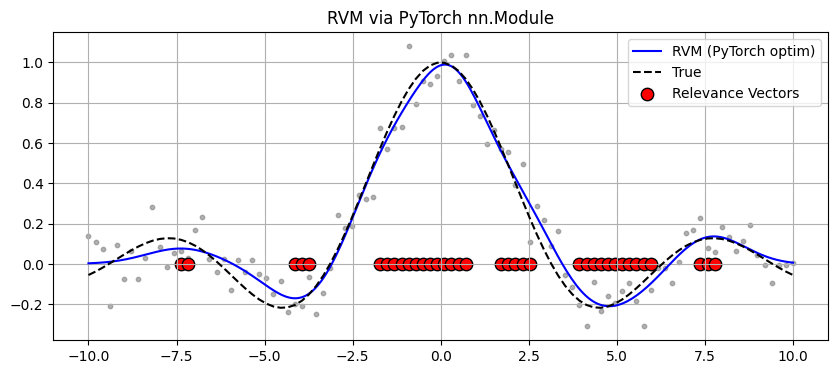

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1. Generate synthetic data
# ----------------------------
torch.manual_seed(42)
N = 100
x = torch.linspace(-10, 10, N)
t_true = torch.sinc(x / np.pi)
noise_std = 0.1
t = t_true + noise_std * torch.randn_like(x)
X = x.unsqueeze(1)  # (N, 1)


# ----------------------------
# 2. RBF kernel
# ----------------------------
def rbf_kernel(X1, X2, length_scale=1.0):
    X1_norm = (X1**2).sum(1).view(-1, 1)
    X2_norm = (X2**2).sum(1).view(1, -1)
    K = X1_norm + X2_norm - 2.0 * X1 @ X2.t()
    return torch.exp(-K / (2 * length_scale**2))


length_scale = 1.0
K_mat = rbf_kernel(X, X, length_scale=length_scale)
Phi = torch.cat([torch.ones(N, 1), K_mat], dim=1)  # (N, N+1)


# ----------------------------
# 3. RVM as nn.Module
# ----------------------------
class RVM(nn.Module):
    def __init__(self, Phi, t):
        super().__init__()
        self.Phi = Phi.detach()  # (N, D)
        self.t = t.detach()  # (N,)
        self.N, self.D = Phi.shape

        # Log-space parameters for positivity
        self.log_alpha = nn.Parameter(
            torch.full((self.D,), -10.0)
        )  # init alpha ≈ 4.5e-5
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))  # init sigma2 = 1

    def forward(self):
        alpha = torch.exp(self.log_alpha)  # (D,)
        sigma2 = torch.exp(self.log_sigma2)  # scalar

        # your code here
        return nll, alpha, sigma2


# ----------------------------
# 4. Training
# ----------------------------
model = RVM(Phi, t)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

losses = []
for epoch in range(500):
    optimizer.zero_grad()
    nll, alpha, sigma2 = model()
    nll.backward()
    optimizer.step()
    losses.append(nll.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, NLL: {nll.item():.4f}, sigma2: {sigma2.item():.4f}")

# ----------------------------
# 5. Extract posterior & predict
# ----------------------------
with torch.no_grad():
    _, alpha_final, sigma2_final = model()
    A = torch.diag(alpha_final)
    beta = 1.0 / sigma2_final
    Sigma = torch.inverse(beta * Phi.t() @ Phi + A)
    mu = beta * Sigma @ Phi.t() @ t

# Prune
pruned = alpha_final > 5e03  # 1e6
relevance_indices = torch.where(~pruned)[0]
print(f"Relevance vectors: {len(relevance_indices)}")

# Prediction
x_test = torch.linspace(-10, 10, 300).unsqueeze(1)
K_test = rbf_kernel(x_test, X, length_scale=length_scale)
Phi_test = torch.cat([torch.ones(300, 1), K_test], dim=1)
y_pred = Phi_test @ mu

# Plot
plt.figure(figsize=(10, 4))
plt.plot(x_test.numpy(), y_pred.numpy(), "b-", label="RVM")
plt.plot(x.numpy(), t_true.numpy(), "k--", label="True")
plt.scatter(x.numpy(), t.numpy(), s=10, c="gray", alpha=0.6)
rv_x = [x[i - 1].item() for i in relevance_indices if i > 0]
plt.scatter(
    rv_x, [0] * len(rv_x), c="red", s=80, edgecolor="k", label="Relevance Vectors"
)
plt.legend()
plt.title("RVM via PyTorch nn.Module")
plt.grid()
plt.show()

## 2. Sparse Bayesian Neural Networks using Automatic Relevance Determination

This notebook implements Sparse Bayesian Neural Networks using Automatic Relevance Determination (ARD), drawing on theoretical foundations from three key papers:

- [Kingma et al., 2015 (arXiv:1506.02557)](https://arxiv.org/abs/1506.02557) introduced Variational Dropout and the Local Reparameterization Trick, showing that Gaussian dropout can be interpreted as variational inference with a scale-invariant log-uniform prior and a factorized Gaussian posterior.

- [Molchanov et al., 2017 (arXiv:1701.05369)](https://arxiv.org/abs/1701.05369) extended Variational Dropout to Sparse Variational Dropout (Sparse VD) by learning individual dropout rates per weight, enabling automatic sparsification. They proposed a tight approximation of the KL-divergence term that works for all dropout rates (including $\alpha \to \infty$), and used additive noise reparameterization to stabilize training.

- [Kharitonov et al., 2018 (arXiv:1811.00596)](https://arxiv.org/abs/1811.00596) reinterpreted Sparse VD through Empirical Bayes and ARD, replacing the improper log-uniform prior with a proper hierarchical Gaussian prior $p(w_{ij}|\lambda_{ij}^2) = \mathcal{N}(0, \lambda_{ij}^2)$. This yields a theoretically sound model that avoids the pitfalls of improper priors while producing comparable sparsity and accuracy.

---

### Model Overview

The implemented model is a Bayesian neural network where each weight $w_{ij}$ is treated as a random variable with:

- Variational posterior:  
  $$
  q_\phi(w_{ij}) = \mathcal{N}(w_{ij} \mid \mu_{ij}, \sigma_{ij}^2)
  $$

- ARD prior:  
  $$
  p(w_{ij} \mid \lambda_{ij}^2) = \mathcal{N}(w_{ij} \mid 0, \lambda_{ij}^2)
  $$

The evidence lower bound (ELBO) is optimized:
$$
\mathcal{L}(\phi) = \underbrace{\mathbb{E}_{q_\phi(w)}[\log p(\mathcal{D} \mid w)]}_{\text{Expected log-likelihood}} - \underbrace{D_{\mathrm{KL}}(q_\phi(w) \,\|\, p(w \mid \lambda^2))}_{\text{Regularization}} \to \max_{\phi, \lambda^2}
$$

Using Empirical Bayes, the optimal prior variance is:
$$
\lambda_{ij}^{2*} = \mu_{ij}^2 + \sigma_{ij}^2
$$

Substituting this back into the evidence lower bound (ELBO) yields the following objective (Kharitonov et al., 2018, Eq. 3):
$$
\mathcal{L}_{\text{ARD}}(\mu, \alpha) = \underbrace{\mathbb{E}_{q(w \mid \mu, \alpha)}[\log p(\mathcal{D} \mid w)]}_{\text{Expected log-likelihood}} \;-\; \underbrace{\frac{1}{2} \sum_{j} \log\left(1 + \alpha_j^{-1}\right)}_{\text{ARD regularizer}} \;\to\; \max_{\mu, \alpha},
$$
where $\alpha_j = \sigma_j^2 / \mu_j^2$ is the local dropout rate for each weight.

---

### Key Implementation Details

#### 1. Bayesian Linear Layer

- Parameters:  
  - `mus` ($\mu_{ij}$): weight means  
  - `log_sigma` ($\log \sigma_{ij}$): log of weight standard deviations (for numerical stability)

-  Forward Pass: Local Reparameterization and Additive Noise

The `BayesianLinear.forward()` method implements the training-time stochastic forward pass using two key techniques:

1. Additive Noise Reparameterization (Molchanov et al., 2017):  
   Instead of the multiplicative form $w_{ij} = \mu_{ij}(1 + \sqrt{\alpha_{ij}}\,\varepsilon_{ij})$, weights are reparameterized as  
   $$
   w_{ij} = \mu_{ij} + \sigma_{ij} \varepsilon_{ij}, \quad \varepsilon_{ij} \sim \mathcal{N}(0,1),
   $$
   which dramatically reduces gradient variance when $\alpha_{ij}$ is large.

2. Local Reparameterization Trick (Kingma et al., 2015):  
   Rather than sampling weights per example, the method samples activations directly. For a fully-connected layer with input matrix $A \in \mathbb{R}^{M \times I}$, weight mean $\Theta \in \mathbb{R}^{I \times O}$, and weight standard deviation $\Sigma \in \mathbb{R}^{I \times O}$, the output activations $B \in \mathbb{R}^{M \times O}$ are computed as (Molchanov et al., 2017, Eq. 17):
   $$
   b_{mj} \sim \mathcal{N}(\gamma_{mj}, \delta_{mj}), \quad \text{where} \quad
   \gamma_{mj} = \sum_{i=1}^{I} a_{mi} \mu_{ij}, \quad
   \delta_{mj} = \sum_{i=1}^{I} a_{mi}^2 \sigma_{ij}^2.
   $$

This formulation ensures that noise is independent across minibatch elements, reduces gradient variance, and enables efficient parallel computation using standard BLAS operations.

- Evaluation (`forward` in eval mode):  
  Prunes weights with high dropout rates ($\log \alpha_{ij} > 3 \Rightarrow p_{\text{drop}} > 0.95$), setting them to zero. Only relevant weights ($\log \alpha_{ij} \leq 3$) are retained.

#### 2. KL Divergence

The KL term is computed analytically using the ARD formulation:
```python
def get_kl(self):
    return 0.5 * torch.log(1 + self.mus.square() / torch.exp(2 * self.log_sigma)).sum()
```
This avoids the need for sampling or approximations used in Sparse VD.

#### 3. Training Protocol

- Warm-up: The KL coefficient (`kl_coef`) is linearly increased from 0 to 1 over epochs to avoid early over-pruning ([Sønderby et al., 2016](https://arxiv.org/abs/1602.02282)).

- Loss:  
  $$
  \mathcal{L} = N \cdot \text{CrossEntropy} + \beta_t \cdot D_{\mathrm{KL}}
  $$
  where $N$ is the dataset size (to scale the likelihood term correctly).

- Numerical Stability: Small constants (`1e-8`) are added to prevent division by zero or log of zero when computing $\log \alpha_{ij}$.

---

### Sparsification Mechanism

The model automatically prunes irrelevant weights during training:

- If a weight is uninformative, the ELBO encourages $\mu_{ij} \to 0$ and $\sigma_{ij}^2 / \mu_{ij}^2 \to \infty$ (i.e., $\log \alpha_{ij} \to \infty$).

- At test time, weights with $\log \alpha_{ij} > 3$ are zeroed out, yielding a sparse deterministic network.


### Linear layer for variational inference with automatic relevance detection

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import transforms

from tqdm import tqdm
import numpy as np

In [ ]:
class BayessianLinear(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(BayessianLinear, self).__init__()

        self.in_dim = in_dim
        self.out_dim = out_dim

        # initialize parameters mu and sigma of q(w|theta)
        # # your code here
        self.mus = 
        self.log_sigma = 

        self.bias = 

    def forward(self, x):
        if self.training:
            # implement local reparametrization trick
            # your code here
            # x shape: batch, in_dim; mus shape: in_dim, out_dim; y shape: batch, out_dim


        # drop all irrelevant weights and use q(w) mean values for the forward pass in eval mode
        # your code here



    def get_kl(self):
        # Calculate kl
        return 0.5*torch.log(1 + self.mus.square()/torch.exp(2*self.log_sigma)).sum()

### Creating MNIST dataset

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

train = torchvision.datasets.MNIST(
    "MNIST", train=True, download=True, transform=transform
)
test = torchvision.datasets.MNIST(
    "MNIST", train=False, download=True, transform=transform
)

train_dl = torch.utils.data.DataLoader(train, batch_size=100, shuffle=True)
test_dl = torch.utils.data.DataLoader(test, batch_size=100, shuffle=True)

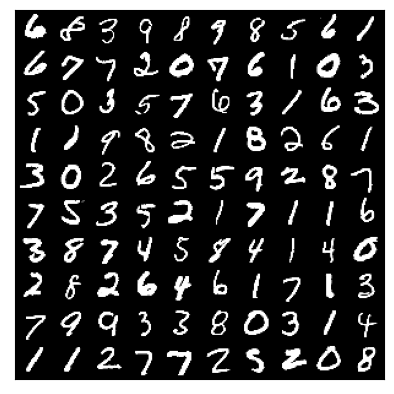

In [3]:
from matplotlib import pyplot as plt

batch = next(iter(train_dl))[0]

plt.imshow(torchvision.utils.make_grid(batch, nrow=10).permute(1, 2, 0).clip(0, 1))
plt.xticks([])
plt.yticks([])
plt.show()

### Training

In [ ]:
model = nn.Sequential(
    BayessianLinear(28 * 28, 300),
    nn.ReLU(),
    BayessianLinear(300, 100),
    nn.ReLU(),
    BayessianLinear(100, 10),
)

opt = optim.Adam(model.parameters(), lr=1e-3)


def calculate_kl(model):
    kl = 0
    for layer in model:
        if isinstance(layer, BayessianLinear):
            kl += layer.get_kl()

    return kl


def calculate_dropped_weights_ratio(model):
    all_weights = 0
    remaining_weights = 0
    for layer in model:
        if isinstance(layer, BayessianLinear):
            all_weights += (
                layer.mus.shape[0] * layer.mus.shape[1] + layer.bias.shape[-1]
            )

            condition = 2 * layer.log_sigma - torch.log(layer.mus**2 + 1e-8) < 3
            remaining_weights += (1.0 * condition).sum()

    return 1 - remaining_weights / all_weights

In [ ]:
epochs = 20

kl_coef = 1.0
delta_kl = 0.05
train_size = len(train_dl.dataset)

# use this criterion to calculate loss
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    kl_coef = min(kl_coef + delta_kl, 1)
    model.train()
    for x, target in tqdm(train_dl):
        opt.zero_grad()
        x = x.reshape(x.shape[0], -1)
        out = model(x)

        # calculate loss, do not forget about kl_coef for warm-up
        # your code here
        kl = calculate_kl(model)
        loss = train_size * criterion(out, target) + kl_coef * kl

        loss.backward()
        opt.step()

    model.eval()
    res = []
    for x, target in tqdm(test_dl):
        res.append(
            (
                (torch.argmax(model(x.reshape(x.shape[0], -1)), dim=1) == target) * 1.0
            ).mean()
        )
    print("test accuracy", np.mean(res))
    print("dropped weights ratio", calculate_dropped_weights_ratio(model))

## Visualization

The visualization shows the first layer weights, masked to display only non-pruned connections ($\log \alpha_{ij} < 3$). The resulting sparsity pattern reveals which input pixels (MNIST image features) are deemed relevant by the model.

In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib as mpl

from matplotlib import rcParams

rcParams["figure.figsize"] = 16, 4
rcParams["figure.dpi"] = 200

log_alpha = 2 * model[0].log_sigma - torch.log(model[0].mus.square() + 1e-8)

mask = (log_alpha.detach().cpu().numpy() < 3).astype(np.float)
W = model[0].mus.detach().cpu().numpy()

# Normalize color map
max_val = np.max(np.abs(mask * W))
norm = mpl.colors.Normalize(vmin=-max_val, vmax=max_val)

plt.imshow(mask * W, cmap="RdBu", interpolation=None, norm=norm)
plt.colorbar()